# AIME quartile delta analysis

This notebook compares each dataset index's eval solve rate against its initial pass@1 baseline from the AIME quartiles dataset.

Expected CSV columns:
- `dataset_index`
- `id`
- `name`
- `solve_rate`

If your CSV does not have a `step` column, the notebook extracts it from `name` when it contains `step_XXXX`.

In [8]:
from __future__ import annotations

import re
from pathlib import Path

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display

def estimate_pass_at_k(num_samples: int, num_correct: int, k: int) -> float:
    """Estimate pass@k for one prompt."""
    if num_samples < 1:
        raise ValueError(f"num_samples must be >= 1, got {num_samples}.")
    if not (0 <= num_correct <= num_samples):
        raise ValueError(
            f"num_correct must satisfy 0 <= num_correct <= num_samples, got {num_correct} with {num_samples}."
        )
    if not (1 <= k <= num_samples):
        raise ValueError(f"k must satisfy 1 <= k <= num_samples, got {k} with {num_samples}.")
    if num_samples - num_correct < k:
        return 1.0
    return 1.0 - (math.comb(num_samples - num_correct, k) / math.comb(num_samples, k))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

DATASET_REPO = "mnoukhov/aime2024-25-rlvr-olmo3-7b-base-pass64-quartiles"
DATASET_SPLIT = "test"
EVAL_CSV_PATH = Path("../notebooks/wandb_export.csv")


In [9]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [re.sub(r"[^0-9a-zA-Z]+", "_", col.strip().lower()).strip("_") for col in df.columns]
    return df


def parse_step_from_name(name: str) -> int:
    match = re.search(r"step_(\d+)", str(name))
    if match is None:
        raise ValueError(f"Could not parse a step from {name!r}")
    return int(match.group(1))


def load_baseline(dataset_repo: str, split: str) -> pd.DataFrame:
    ds = load_dataset(dataset_repo, split=split)
    df = normalize_columns(ds.to_pandas())

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            df["dataset_index"] = np.arange(len(df), dtype=int)

    if "pass_count" not in df.columns:
        if "pass_rate" not in df.columns:
            raise ValueError("The baseline dataset needs pass_count or pass_rate.")
        df["pass_count"] = df["pass_rate"].map(lambda value: int(str(value).split("/", 1)[0]))

    required_columns = {"dataset_index", "dataset", "num_samples", "pass_count"}
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["num_samples"] = pd.to_numeric(df["num_samples"], errors="raise").astype(int)
    df["pass_count"] = pd.to_numeric(df["pass_count"], errors="raise").astype(int)
    df["initial_pass_at_1"] = [
        estimate_pass_at_k(num_samples=int(num_samples), num_correct=int(pass_count), k=1)
        for pass_count, num_samples in zip(df["pass_count"], df["num_samples"])
    ]
    df["quartile"] = df["dataset"].astype(str).str.extract(r"quartile(\d+)").astype("Int64")

    return df[["dataset_index", "dataset", "quartile", "pass_count", "num_samples", "initial_pass_at_1"]]


def load_eval_csv(path: Path) -> pd.DataFrame:
    df = normalize_columns(pd.read_csv(path))

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            raise ValueError("The eval CSV needs a dataset_index column.")

    if "solve_rate" not in df.columns:
        if "pass_rate" in df.columns:
            df = df.rename(columns={"pass_rate": "solve_rate"})
        else:
            raise ValueError("The eval CSV needs a solve_rate column.")

    if "step" not in df.columns:
        if "name" not in df.columns:
            raise ValueError("The eval CSV needs either a step column or a name column containing step_XXXX.")
        df["step"] = df["name"].map(parse_step_from_name)

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["solve_rate"] = pd.to_numeric(df["solve_rate"], errors="raise")
    df["step"] = pd.to_numeric(df["step"], errors="raise").astype(int)

    return df


In [10]:
baseline = load_baseline(DATASET_REPO, DATASET_SPLIT)
eval_df = load_eval_csv(EVAL_CSV_PATH)

merged = eval_df.merge(
    baseline,
    on="dataset_index",
    how="left",
    validate="many_to_one",
)
merged["delta_vs_initial_pass_at_1"] = merged["solve_rate"] - merged["initial_pass_at_1"]
merged = merged.sort_values(["quartile", "dataset_index", "step"]).reset_index(drop=True)

display(merged.head())
display(merged[["step", "delta_vs_initial_pass_at_1"]].groupby("step", as_index=False).mean())


,dataset_index,id,name,solve_rate,step,dataset,quartile,pass_count,num_samples,initial_pass_at_1,delta_vs_initial_pass_at_1
0,0,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.781250,200,math_aime_quartile0,0,22,64,0.34375,0.437500
1,0,eh5wi7gu,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.859375,400,math_aime_quartile0,0,22,64,0.34375,0.515625
2,0,yoqi90ri,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.906250,600,math_aime_quartile0,0,22,64,0.34375,0.562500
3,0,p9bx5c8r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.953125,800,math_aime_quartile0,0,22,64,0.34375,0.609375
4,0,j29e73ju,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.906250,1000,math_aime_quartile0,0,22,64,0.34375,0.562500


,step,delta_vs_initial_pass_at_1
0,200,0.125000
1,400,0.137760
2,600,0.159896
3,800,0.166406
4,1000,0.185677
5,1200,0.191667
6,1400,0.189844
7,1600,0.199740
8,1800,0.210677
9,2000,0.209896


In [11]:
eval_df

,dataset_index,id,name,solve_rate,step
0,0,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.968750,2400
1,1,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.984375,2400
2,2,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,1.000000,2400
3,3,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.984375,2400
4,4,38gax9ly,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.406250,2400
...,...,...,...,...,...
835,55,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.000000,200
836,56,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.031250,200
837,57,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.000000,200
838,58,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.015625,200


## Delta over steps

The first plot shows the mean delta across all dataset indices. The second breaks that mean delta out by quartile.

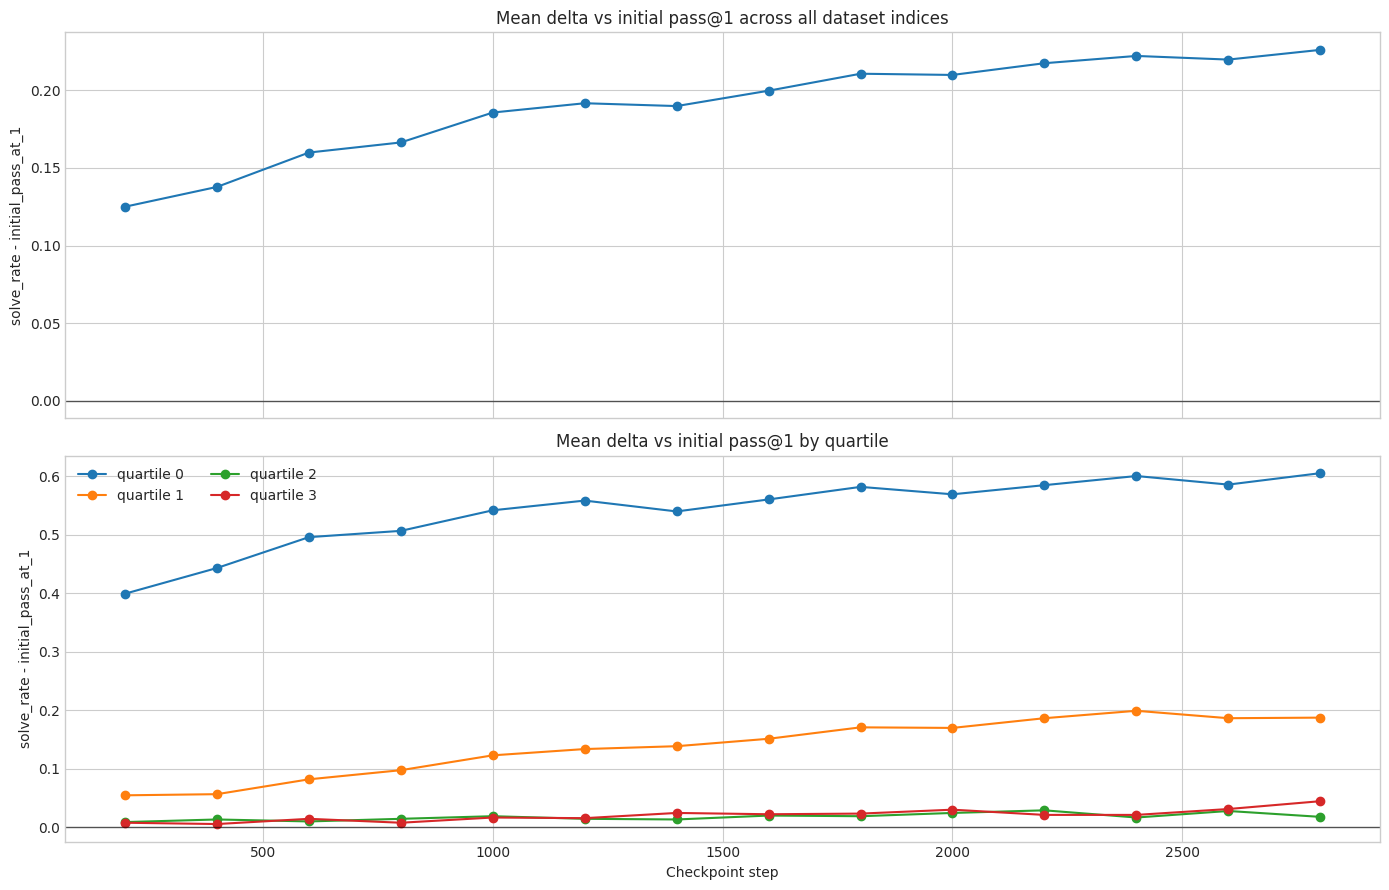

In [9]:
step_summary = merged.groupby("step", as_index=False)["delta_vs_initial_pass_at_1"].mean()
quartile_summary = (
    merged.groupby(["step", "quartile"], as_index=False)["delta_vs_initial_pass_at_1"].mean().sort_values(["quartile", "step"])
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(step_summary["step"], step_summary["delta_vs_initial_pass_at_1"], marker="o")
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_title("Mean delta vs initial pass@1 across all dataset indices")
axes[0].set_ylabel("solve_rate - initial_pass_at_1")

for quartile, subset in quartile_summary.groupby("quartile"):
    axes[1].plot(subset["step"], subset["delta_vs_initial_pass_at_1"], marker="o", label=f"quartile {int(quartile)}")

axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[1].set_title("Mean delta vs initial pass@1 by quartile")
axes[1].set_xlabel("Checkpoint step")
axes[1].set_ylabel("solve_rate - initial_pass_at_1")
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()


## Heatmap by dataset index

This is the most direct view of the difference between the initial baseline and each eval checkpoint for every dataset index.

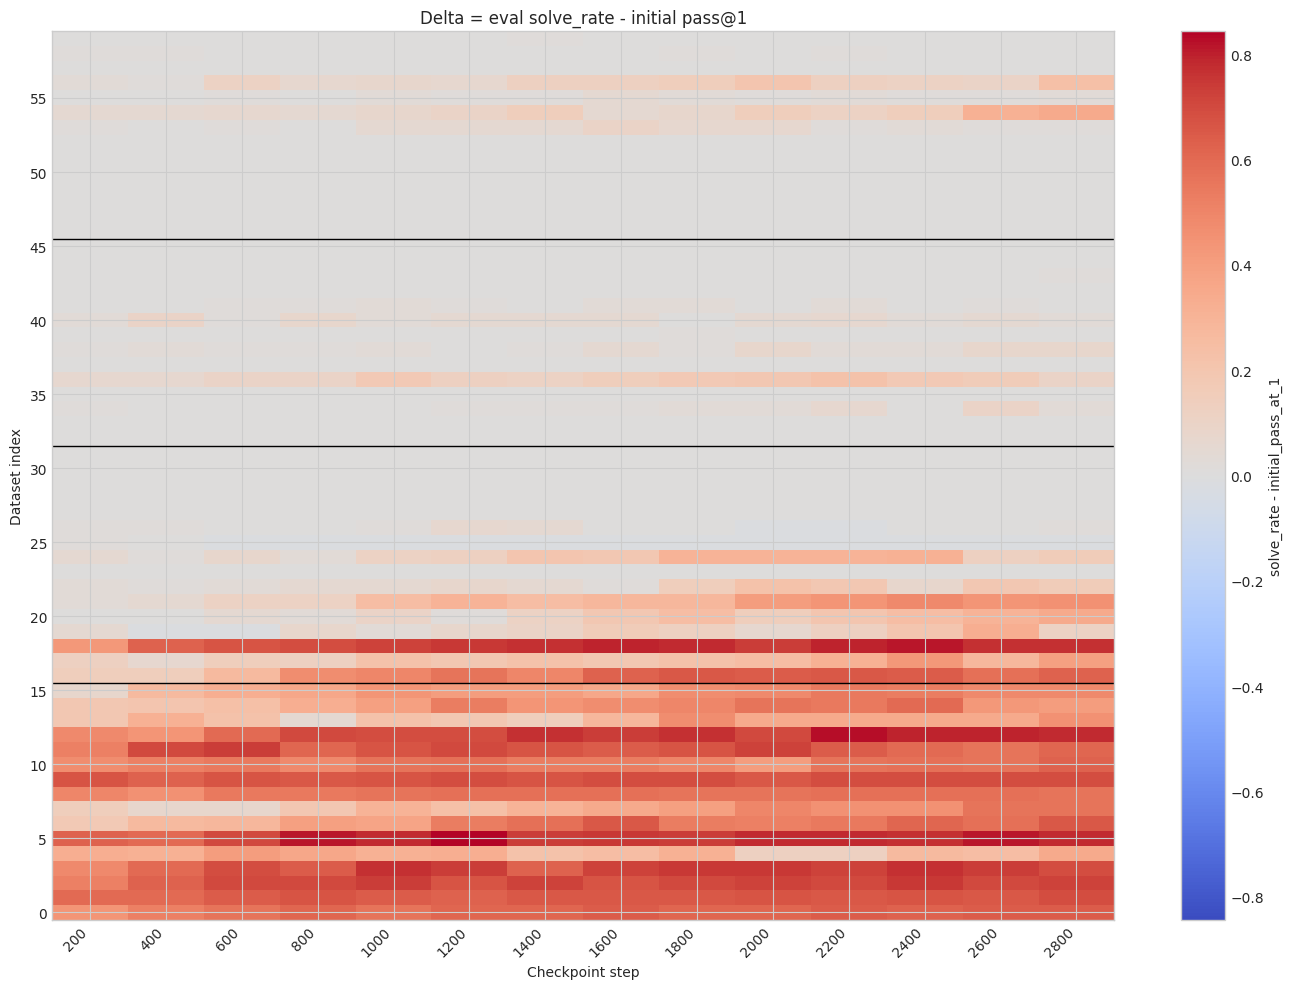

In [17]:
row_order = baseline.sort_values(["quartile", "dataset_index"])["dataset_index"].tolist()
heatmap = (
    merged.pivot_table(
        index="dataset_index",
        columns="step",
        values="delta_vs_initial_pass_at_1",
        aggfunc="mean",
    )
    .reindex(row_order)
    .sort_index(axis=1)
)

heatmap_values = heatmap.to_numpy(dtype=float)
max_abs = float(np.nanmax(np.abs(heatmap_values))) if np.isfinite(heatmap_values).any() else 1.0
max_abs = max(max_abs, 1e-9)

fig, ax = plt.subplots(figsize=(14, 10))
image = ax.imshow(
    heatmap_values,
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs,
)

ax.set_title("Delta = eval solve_rate - initial pass@1")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("Dataset index")
ax.set_xticks(np.arange(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns.tolist(), rotation=45, ha="right")

tick_positions = np.arange(0, len(heatmap.index), max(1, len(heatmap.index) // 12))
ax.set_yticks(tick_positions)
ax.set_yticklabels([int(heatmap.index[i]) for i in tick_positions])

quartile_sizes = baseline.sort_values(["quartile", "dataset_index"]).groupby("quartile").size().tolist()
boundary = 0
for size in quartile_sizes[:-1]:
    boundary += size
    ax.axhline(boundary - 0.5, color="black", linewidth=1)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("solve_rate - initial_pass_at_1")
plt.tight_layout()
plt.show()


## Inspect a single dataset index

Set `DATASET_INDEX_TO_PLOT` to any row index you want to inspect in detail.

,step,dataset_index,dataset,solve_rate,initial_pass_at_1,delta_vs_initial_pass_at_1,name
0,200,0,math_aime_quartile0,0.781250,0.34375,0.437500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
1,400,0,math_aime_quartile0,0.859375,0.34375,0.515625,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
2,600,0,math_aime_quartile0,0.906250,0.34375,0.562500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
3,800,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
4,1000,0,math_aime_quartile0,0.906250,0.34375,0.562500,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
5,1200,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
6,1400,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
7,1600,0,math_aime_quartile0,0.984375,0.34375,0.640625,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
8,1800,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...
9,2000,0,math_aime_quartile0,0.953125,0.34375,0.609375,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...


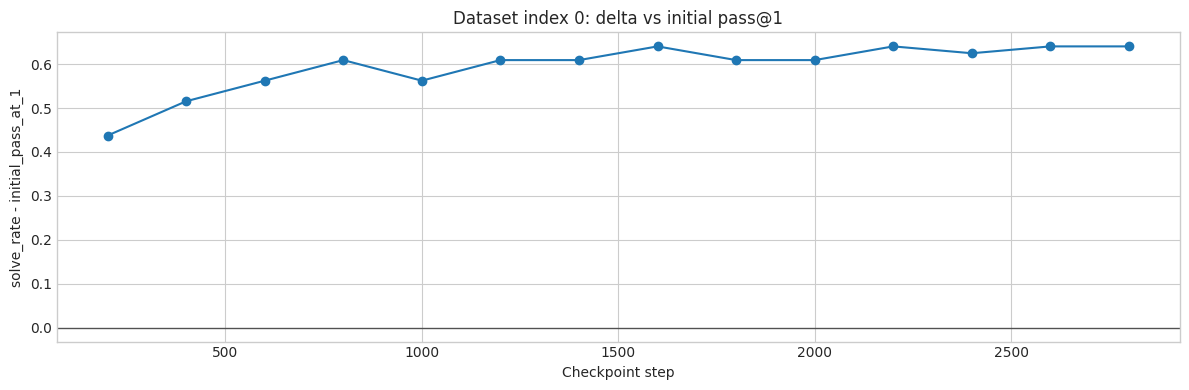

In [11]:
DATASET_INDEX_TO_PLOT = 0

one_index = merged[merged["dataset_index"] == DATASET_INDEX_TO_PLOT].sort_values("step").copy()
display(
    one_index[
        ["step", "dataset_index", "dataset", "solve_rate", "initial_pass_at_1", "delta_vs_initial_pass_at_1", "name"]
    ]
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_index["step"], one_index["delta_vs_initial_pass_at_1"], marker="o")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.set_title(f"Dataset index {DATASET_INDEX_TO_PLOT}: delta vs initial pass@1")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("solve_rate - initial_pass_at_1")
plt.tight_layout()
plt.show()


## Quartile pass@1: initial vs final RL checkpoint

For each difficulty quartile, this bar plot shows the initial mean pass@1 in grey and stacks the increase achieved by the final RL checkpoint in green.

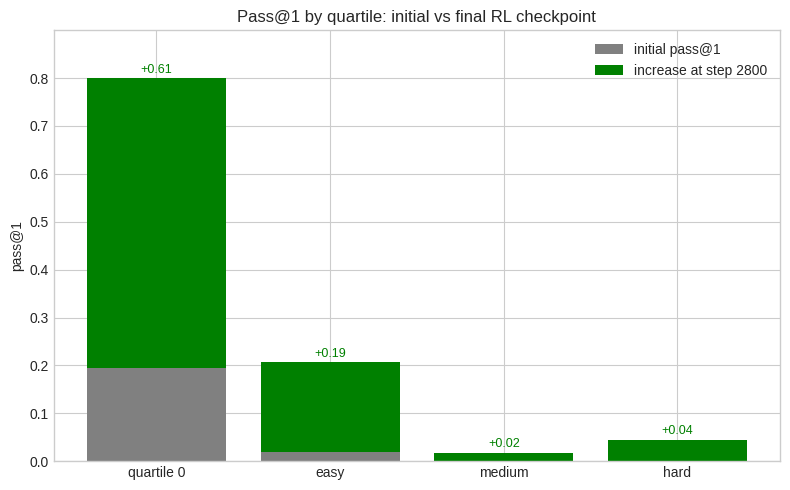

In [12]:
QUARTILE_LABELS = {1: "easy", 2: "medium", 3: "hard", 4: "extra hard"}

final_step = int(merged["step"].max())
final_df = merged[merged["step"] == final_step]

quartile_stats = (
    final_df.groupby("quartile")
    .agg(initial=("initial_pass_at_1", "mean"), final=("solve_rate", "mean"))
    .sort_index()
)
quartile_stats["delta"] = (quartile_stats["final"] - quartile_stats["initial"]).clip(lower=0)

quartiles = quartile_stats.index.astype(int).tolist()
labels = [QUARTILE_LABELS.get(q, f"quartile {q}") for q in quartiles]
initial = quartile_stats["initial"].to_numpy()
delta = quartile_stats["delta"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(quartiles))
ax.bar(x, initial, color="grey", label="initial pass@1")
ax.bar(x, delta, bottom=initial, color="green", label=f"increase at step {final_step}")

for xi, init_val, delta_val in zip(x, initial, delta):
    ax.text(xi, init_val + delta_val + 0.005, f"+{delta_val:.2f}", ha="center", va="bottom", color="green", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("pass@1")
ax.set_title("Pass@1 by quartile: initial vs final RL checkpoint")
ax.set_ylim(0, min(1.0, float((initial + delta).max()) + 0.1))
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
per_example = (
    final_df[["dataset_index", "quartile", "initial_pass_at_1", "solve_rate"]]
    .rename(columns={"solve_rate": "final_pass_at_1"})
    .copy()
)
per_example["difficulty"] = per_example["quartile"].astype(int).map(QUARTILE_LABELS)
per_example["delta"] = per_example["final_pass_at_1"] - per_example["initial_pass_at_1"]
per_example = per_example.sort_values(["quartile", "dataset_index"]).reset_index(drop=True)
per_example = per_example[["dataset_index", "difficulty", "initial_pass_at_1", "final_pass_at_1", "delta"]]

with pd.option_context("display.max_rows", None):
    display(per_example)

,dataset_index,difficulty,initial_pass_at_1,final_pass_at_1,delta
0,0,NaN,0.343750,0.984375,0.640625
1,1,NaN,0.312500,1.000000,0.687500
2,2,NaN,0.250000,0.968750,0.718750
3,3,NaN,0.218750,0.906250,0.687500
4,4,NaN,0.140625,0.484375,0.343750
5,5,NaN,0.109375,0.890625,0.781250
6,6,NaN,0.093750,0.750000,0.656250
7,7,NaN,0.078125,0.640625,0.562500
8,8,NaN,0.421875,0.984375,0.562500
9,9,NaN,0.312500,1.000000,0.687500


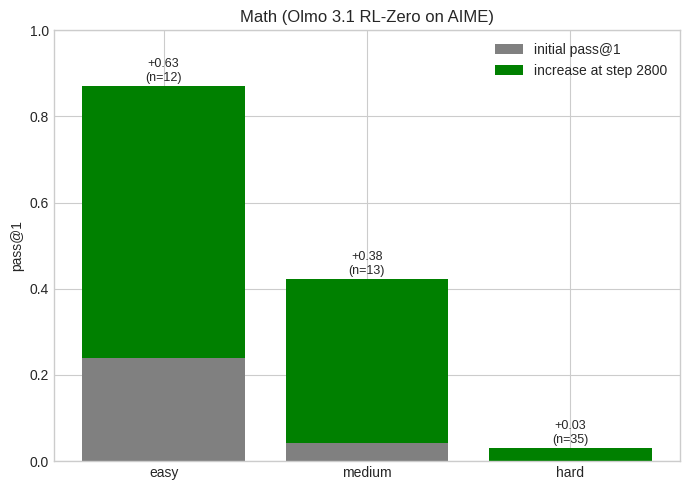

In [19]:
final_with_pc = final_df[["dataset_index", "pass_count", "initial_pass_at_1", "solve_rate"]].copy()

hard_mask = final_with_pc["pass_count"] == 0
hard = final_with_pc[hard_mask]
remainder = final_with_pc[~hard_mask].sort_values("initial_pass_at_1", ascending=False).reset_index(drop=True)

split_point = len(remainder) // 2
easy = remainder.iloc[:split_point]
medium = remainder.iloc[split_point:]

groups = {"easy": easy, "medium": medium, "hard": hard}
labels = list(groups.keys())
initial_means = np.array([g["initial_pass_at_1"].mean() if len(g) else 0.0 for g in groups.values()])
final_means = np.array([g["solve_rate"].mean() if len(g) else 0.0 for g in groups.values()])
deltas = np.clip(final_means - initial_means, a_min=0, a_max=None)
counts = [len(g) for g in groups.values()]

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(labels))
ax.bar(x, initial_means, color="grey", label="initial pass@1")
ax.bar(x, deltas, bottom=initial_means, color="green", label=f"increase at step {final_step}")

for xi, init_val, delta_val, n in zip(x, initial_means, deltas, counts):
    ax.text(xi, init_val + delta_val + 0.005, f"+{delta_val:.2f}\n(n={n})", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("pass@1")
ax.set_title("Math (Olmo 3.1 RL-Zero on AIME)")
ax.set_ylim(0, min(1.0, float((initial_means + deltas).max()) + 0.15))
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
extracted_buckets = [
    {"bucket": "0/8", "group": "extra hard", "n": 99,  "base": 0,   "after_rl": 5,  "delta": 5},
    {"bucket": "1/8", "group": "hard",       "n": 9,   "base": 12,  "after_rl": 18, "delta": 6},
    {"bucket": "2/8", "group": "hard",       "n": 8,   "base": 25,  "after_rl": 48, "delta": 23},
    {"bucket": "3/8", "group": "hard",       "n": 6,   "base": 38,  "after_rl": 44, "delta": 6},
    {"bucket": "4/8", "group": "medium",     "n": 8,   "base": 50,  "after_rl": 67, "delta": 17},
    {"bucket": "5/8", "group": "medium",     "n": 10,  "base": 62,  "after_rl": 89, "delta": 26},
    {"bucket": "6/8", "group": "medium",     "n": 23,  "base": 75,  "after_rl": 92, "delta": 17},
    {"bucket": "7/8", "group": "easy",       "n": 15,  "base": 88,  "after_rl": 92, "delta": 4},
    {"bucket": "8/8", "group": "easy",       "n": 101, "base": 100, "after_rl": 98, "delta": -2},
]

initial_pass_rate_to_increase_after_rl = {
    0: 5,
    12: 6,
    25: 23,
    38: 6,
    50: 17,
    62: 26,
    75: 17,
    88: 4,
    100: -2,
}

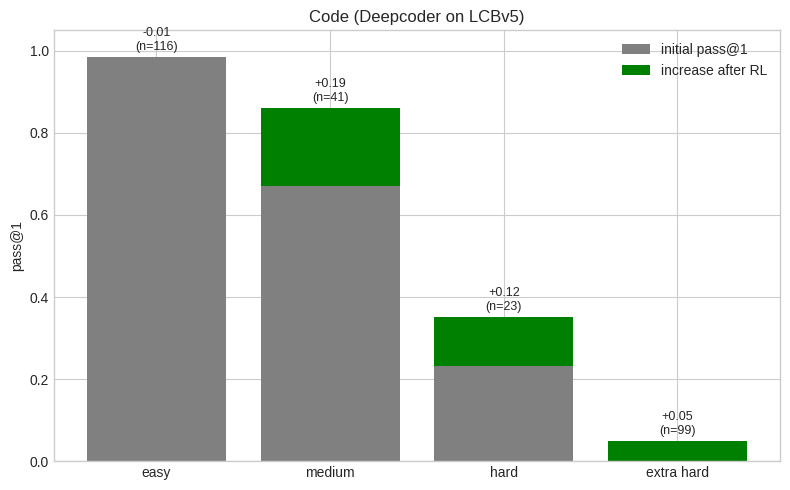

In [18]:
CODE_GROUPS = {
    "easy": {"7/8", "8/8"},
    "medium": {"4/8", "5/8", "6/8"},
    "hard": {"1/8", "2/8", "3/8"},
    "extra hard": {"0/8"},
}

buckets_df = pd.DataFrame(extracted_buckets)

group_labels = ["easy", "medium", "hard", "extra hard"]
initial_means = []
delta_means = []
counts = []
for label in group_labels:
    sub = buckets_df[buckets_df["bucket"].isin(CODE_GROUPS[label])]
    n = sub["n"].sum()
    counts.append(int(n))
    if n > 0:
        initial_means.append((sub["base"] * sub["n"]).sum() / n / 100.0)
        delta_means.append((sub["delta"] * sub["n"]).sum() / n / 100.0)
    else:
        initial_means.append(0.0)
        delta_means.append(0.0)

initial_means = np.array(initial_means)
delta_means = np.array(delta_means)
positive_delta = np.clip(delta_means, a_min=0, a_max=None)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(group_labels))
ax.bar(x, initial_means, color="grey", label="initial pass@1")
ax.bar(x, positive_delta, bottom=initial_means, color="green", label="increase after RL")

for xi, init_val, delta_val, n in zip(x, initial_means, delta_means, counts):
    top = init_val + max(delta_val, 0)
    sign = "+" if delta_val >= 0 else ""
    ax.text(xi, top + 0.01, f"{sign}{delta_val:.2f}\n(n={n})", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(group_labels)
ax.set_ylabel("pass@1")
ax.set_title("Code (Deepcoder on LCBv5)")
ax.set_ylim(0, min(1.05, float((initial_means + positive_delta).max()) + 0.15))
ax.legend()
plt.tight_layout()
plt.show()